# Practical Class 1 — Signal Representation

This notebook reviews time-domain and frequency-domain signal representations using Python and NumPy, in the context of mixed-signal converter design.

In [1]:
import numpy as np
from numpy.random import normal, uniform
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import scienceplots  # noqa: F401

plt.style.use(["science", "notebook"])
%matplotlib inline

## 1. Signal Representation in the Time Domain

A signal — whether a voltage, current, or digital code — can be decomposed into a sum of fundamental trigonometric functions (Fourier's theorem). Two key aspects are explored:

1. **Fourier decomposition** — any periodic signal can be represented as an infinite sum of sines and cosines at harmonic frequencies.
2. **Differential signaling** — processing signals differentially cancels even-order harmonic distortion, improving linearity.

### Simulation Time Base

The number of simulation points $N_p$ controls the time-domain resolution and directly affects computation time and memory usage. The discrete time vector is constructed as $t[n] = n \cdot T_s$ for $n = 0, 1, \ldots, N_p - 1$, where $T_s = 1/F_s$ is the sampling period.

> **MATLAB equivalent:** `(0:Np-1)` corresponds to `np.arange(0, Np)` in NumPy.

In [2]:
Np = 1001
Fs = 100e3
Ts = 1 / Fs
tD = np.arange(0, Np) * Ts

In [3]:
Amp1 = 1
f1 = 1e3
phase1 = 0
phase1_rad = np.deg2rad(phase1)
x1 = Amp1 * np.sin(2 * np.pi * f1 * tD + phase1_rad)

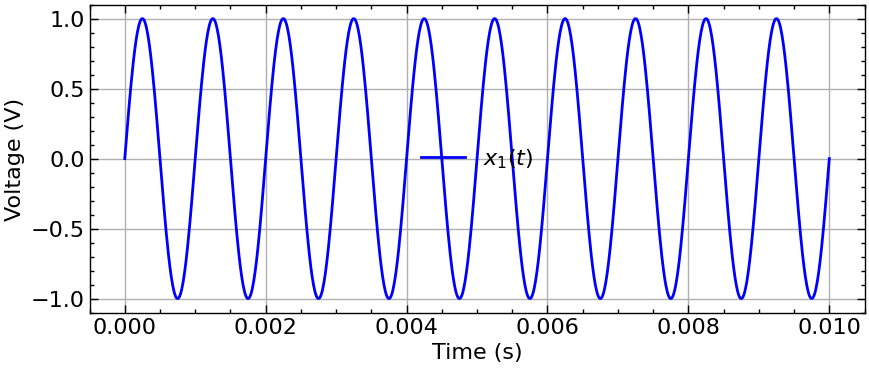

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(tD, x1, lw=2, ls="-", color="b", ms=3, label=r"$x_1(t)$")
ax.grid(True)
ax.set_ylabel("Voltage (V)")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()

In [5]:
Amp2 = 1
f2 = 0.5e3
phase2 = 0
phase2_rad = np.deg2rad(phase2)
x2 = Amp2 * np.sin(2 * np.pi * f2 * tD + phase2_rad)

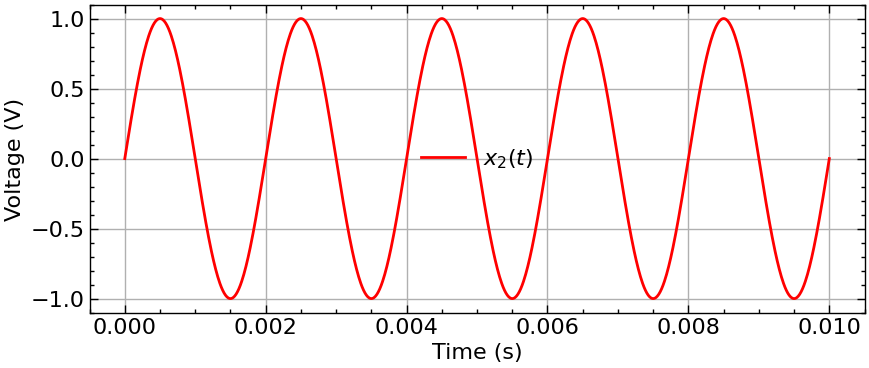

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(tD, x2, lw=2, ls="-", color="r", ms=3, label=r"$x_2(t)$")
ax.grid(True)
ax.set_ylabel("Voltage (V)")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()

### Harmonics and Fourier Series Intuition

A signal can be represented as a sum of sinusoids at integer multiples of a fundamental frequency $f_1$. The second harmonic has frequency $f_2 = 2f_1$ and the third has $f_3 = 3f_1$. Below, `x2` and `x3` are redefined as the second and third harmonics of `x1`.

In [7]:
Amp2 = 0.5
f2 = 2 * f1
phase2_rad = np.deg2rad(0)
x2 = Amp2 * np.sin(2 * np.pi * f2 * tD + phase2_rad)

Amp3 = 0.2
f3 = 3 * f1
phase3_rad = np.deg2rad(0)
x3 = Amp3 * np.sin(2 * np.pi * f3 * tD + phase3_rad)

Observe how the superposition of harmonics shapes the resulting waveform. Summing $x_1$ with its odd harmonic $x_3$ begins to approximate a square wave — a direct consequence of the Fourier series, where a square wave is composed exclusively of odd harmonics.

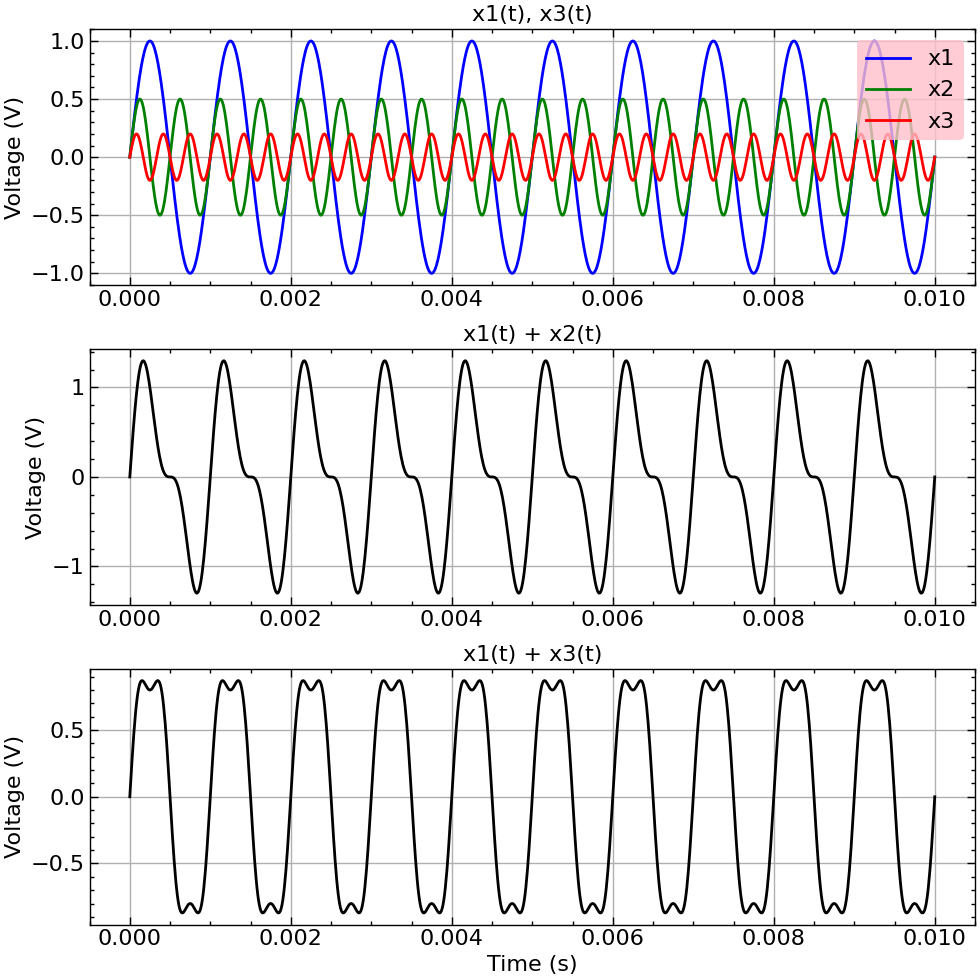

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(tD, x1, lw=2, ls="-", color="b", marker="None", ms=3, label="x1")
ax[0].plot(tD, x2, lw=2, ls="-", color="g", marker="None", ms=3, label="x2")
ax[0].plot(tD, x3, lw=2, ls="-", color="r", marker="None", ms=3, label="x3")
ax[0].set_title("x1(t), x3(t)")
ax[0].legend(frameon=True, facecolor="pink", edgecolor="none")
ax[0].grid(True)
ax[0].set_ylabel("Voltage (V)")
ax[1].plot(tD, x1 + x2, lw=2, ls="-", color="k", marker="None", ms=3)
ax[1].set_title("x1(t) + x2(t)")
ax[1].grid(True)
ax[1].set_ylabel("Voltage (V)")
ax[2].plot(tD, x1 + x3, lw=2, ls="-", color="k", marker="None", ms=3)
ax[2].set_title("x1(t) + x3(t)")
ax[2].grid(True)
ax[2].set_ylabel("Voltage (V)")
ax[2].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

### Observations

- **Odd harmonics** preserve the waveform symmetry about its mean value. Square waves, for instance, contain only odd harmonics.
- **Even harmonics** break this symmetry, skewing the positive and negative half-cycles unequally.

### Differential Signaling

A signal processing or conversion chain should be **differential**: the two signal paths carry waveforms that are $180^\circ$ out of phase. Differential operation naturally cancels even-order harmonic distortion, improving output linearity.

**Demonstration.** Consider a single-tone input $x(t) = A \sin(2\pi f_1 t)$ passed through a weakly nonlinear system modeled by a power series:

$$
y(t) = \alpha_1 x(t) + \alpha_2 x^2(t) + \alpha_3 x^3(t)
$$

Applying trigonometric power-reduction identities, the output contains components at DC, $f_1$, $2f_1$, and $3f_1$:

$$
y(t) = \frac{\alpha_2 A^2}{2} + \left(\alpha_1 A + \frac{3\alpha_3 A^3}{4}\right)\sin(2\pi f_1 t) - \frac{\alpha_2 A^2}{2}\cos(4\pi f_1 t) - \frac{\alpha_3 A^3}{4}\sin(6\pi f_1 t)
$$

For the anti-phase input $x'(t) = -x(t)$, the even-order terms ($\alpha_2$ contributions) remain unchanged in sign, while the odd-order terms flip. Subtracting:

$$
y(t) - y'(t) = 2\left(\alpha_1 A + \frac{3\alpha_3 A^3}{4}\right)\sin(2\pi f_1 t) - \frac{\alpha_3 A^3}{2}\sin(6\pi f_1 t)
$$

The even-order ($2f_1$) component and DC offset are **eliminated**, reducing total harmonic distortion.

## 2. Signal Representation in the Frequency Domain

The Fourier transform maps a time-domain signal to its frequency-domain representation. The composite signal $x_1 + x_2 + x_3$ should produce three spectral peaks at $f_1$, $2f_1$, and $3f_1$, corresponding to the fundamental, second, and third harmonics.

The FFT output is normalized by dividing by the number of points $N_p$, converting the transform from total energy to per-sample amplitude. The power spectrum is then $|X(f)|^2$.

In [9]:
yt = x1 + x2 + x3
yf = np.abs(np.fft.fftshift(np.fft.fft(yt) / Np))  # [V]
fD = np.fft.fftshift(np.fft.fftfreq(Np, Ts))  # [Hz]
power_yf = yf * yf  # [V^2]
power_yf_dB = 10 * np.log10(power_yf)  # [dB]

yf2 = np.abs(np.fft.fftshift(np.fft.fft(x1) / Np))  # [V]
power_yf2 = yf2 * yf2  # [V^2]
power_yf2_dB = 10 * np.log10(power_yf2)  # [dB]

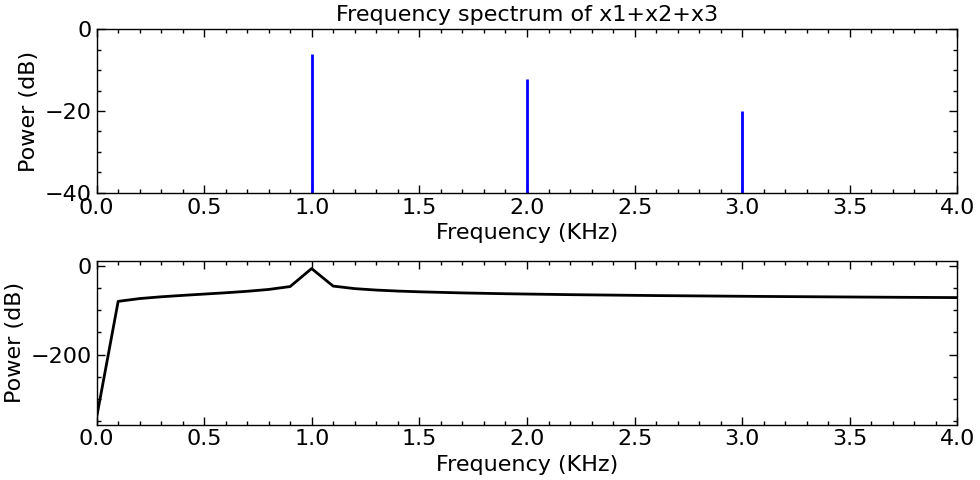

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
f_scale = 1e3  # [Hz]
p_scale = 1  # [dB]
ax[0].stem(
    fD[fD >= 0] / f_scale,
    power_yf_dB[fD >= 0] / p_scale,
    bottom=np.min(power_yf_dB / p_scale),
    linefmt="b-",
    markerfmt="none",
    basefmt="r-",
)
ax[0].set_xlabel("Frequency (KHz)")
ax[0].set_ylabel("Power (dB)")
ax[0].set_title("Frequency spectrum of x1+x2+x3")
f_lim = 4e3 / f_scale
ax[0].set_xlim([0, f_lim])
ax[0].set_ylim([-40, 0])
ax[1].plot(
    fD[fD >= 0] / f_scale,
    power_yf2_dB[fD >= 0] / p_scale,
    ls="-",
    color="k",
    marker="none",
)
ax[1].set_xlabel("Frequency (KHz)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_xlim([0, f_lim])
fig.tight_layout()

### Spectral Leakage

The spectrum of $x_1$ alone shows energy spreading across many frequency bins instead of concentrating at a single bin. This is **spectral leakage**, caused by the finite observation window truncating the signal.

### 2.1 Windowing

Multiplying the time-domain signal by a window function (e.g., Blackman-Harris) tapers the signal edges toward zero, concentrating each harmonic's energy into fewer bins and dramatically reducing leakage. The trade-off is a wider main lobe: the Blackman-Harris window spreads each harmonic across approximately 5 bins.

> **Note:** An alternative (and often preferred) approach is **coherent sampling** — choosing $F_s$ and $N_p$ such that the signal completes an integer number of cycles within the observation window, with the number of cycles being coprime to $N_p$. Both techniques can be combined.

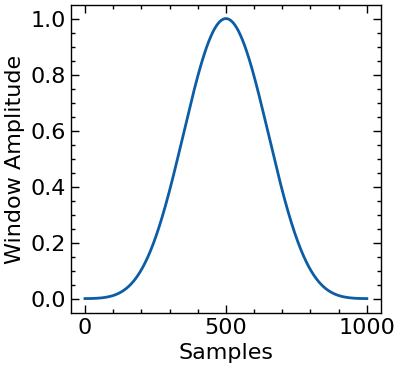

In [11]:
window = signal.windows.blackmanharris(Np)
fig, ax = plt.subplots(1, figsize=(4, 4))
ax.set_xlabel("Samples")
ax.set_ylabel("Window Amplitude")
plt.plot(window)

In [12]:
ytbm = yt * signal.windows.blackmanharris(Np)
yfbm = np.abs(np.fft.fftshift(np.fft.fft(ytbm) / Np))  # [V]
power_yfbm = yfbm * yfbm  # [V^2]
power_yfbm_dB = 10 * np.log10(power_yfbm)  # [dB]

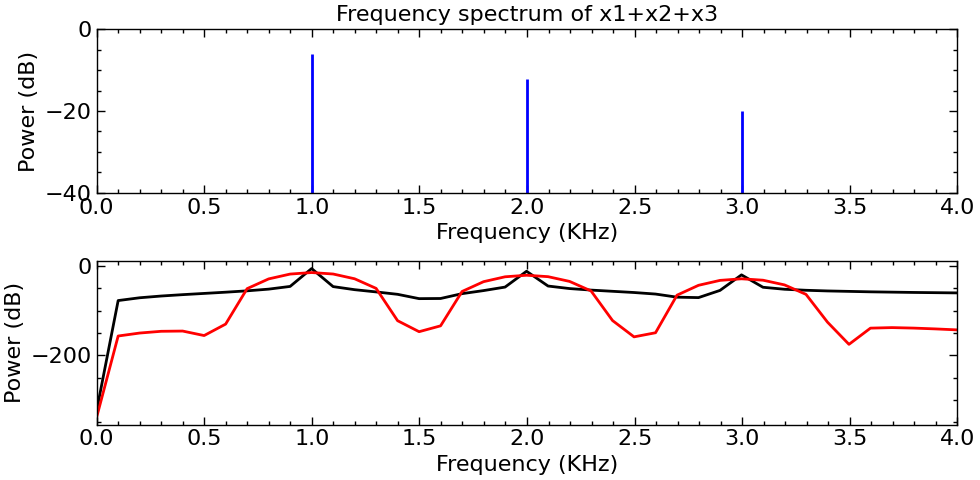

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
f_scale = 1e3  # [Hz]
p_scale = 1  # [dB]
ax[0].stem(
    fD[fD >= 0] / f_scale,
    power_yf_dB[fD >= 0] / p_scale,
    bottom=np.min(power_yf_dB / p_scale),
    linefmt="b-",
    markerfmt="none",
    basefmt="r-",
)
ax[0].set_xlabel("Frequency (KHz)")
ax[0].set_ylabel("Power (dB)")
ax[0].set_title("Frequency spectrum of x1+x2+x3")
f_lim = 4e3 / f_scale
ax[0].set_xlim([0, f_lim])
ax[0].set_ylim([-40, 0])
ax[1].plot(
    fD[fD >= 0] / f_scale,
    power_yf_dB[fD >= 0] / p_scale,
    ls="-",
    color="k",
    marker="none",
)
ax[1].plot(
    fD[fD >= 0] / f_scale,
    power_yfbm_dB[fD >= 0] / p_scale,
    ls="-",
    color="r",
    marker="none",
)
ax[1].set_xlabel("Frequency (KHz)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_xlim([0, f_lim])
fig.tight_layout()

## 3. White Noise and Quantization Noise

Accurate simulation of signal converters requires modeling noise. Quantizing an ideal, noiseless signal introduces a **quantization error**:

$$
s_Q(t) = s(t) + \varepsilon_Q(t) \tag{1}
$$

where $s(t)$ is the input signal, $\varepsilon_Q(t)$ is the quantization error, and $s_Q(t)$ is the quantized output.

In practice, analog signals always carry some noise $n(t)$. When the superimposed noise power is sufficiently large relative to the quantization step, the quantization error is well approximated by **white noise** — a signal with flat (constant) power spectral density across the entire bandwidth:

$$
s_Q(t) = \bigl(x(t) + n(t)\bigr) + \varepsilon_Q(t) = x(t) + v_{NQ}(t) \tag{2}
$$

where $v_{NQ}(t) \approx n(t) + \varepsilon_Q(t)$ is the effective noise, commonly modeled as a uniform distribution over $[-V_\text{LSB}/2,\; V_\text{LSB}/2]$.

### 3.1 Uniform (Quantization) Noise

A quantizer with $N$ bits and reference voltage $V_\text{ref}$ has a step size $V_\text{LSB} = V_\text{ref} / 2^N$. The quantization noise variance is $\sigma_Q^2 = V_\text{LSB}^2 / 12$.

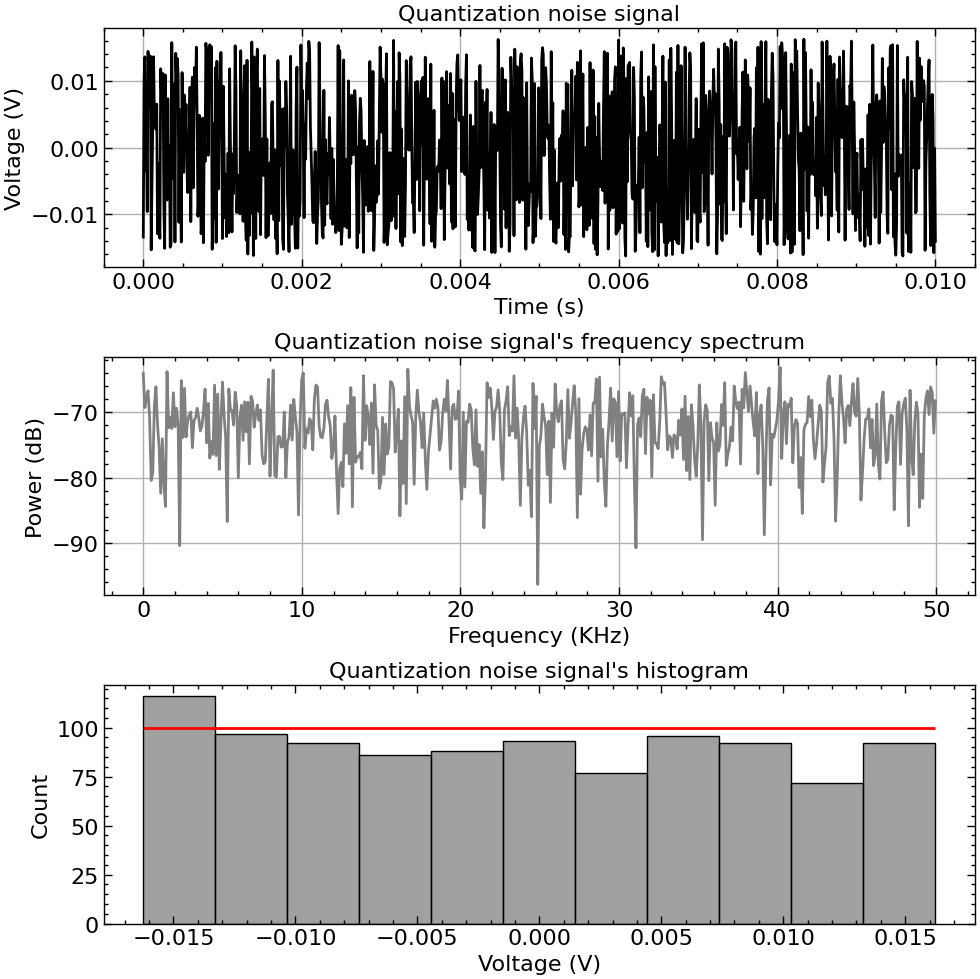

In [14]:
nbits = 4
vref = 0.9  # [V]
vlsb = vref / (2**nbits)  # [V]

vqmean = 0  # [V]
vqvar = (vlsb**2) / 12  # [V^2]
vqstddev = np.sqrt(vqvar)  # [V]

vq = uniform(-vqstddev, vqstddev, Np)  # [V]

vqf = np.abs(np.fft.fftshift(np.fft.fft(vq) / Np))  # [V]
pqf = vqf * vqf  # [V^2]
pqf_dB = 10 * np.log10(pqf)  # [dB]

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(tD, vq, ls="-", color="k", marker="none")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Voltage (V)")
ax[0].set_title("Quantization noise signal")
ax[1].plot(
    fD[fD >= 0] / f_scale,
    pqf_dB[fD >= 0] / p_scale,
    ls="-",
    color="gray",
    marker="none",
)
ax[1].set_xlabel("Frequency (KHz)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_title("Quantization noise signal's frequency spectrum")
sns.histplot(vq, ax=ax[2], color="gray")
ax[2].hlines(
    y=np.mean(np.histogram(vq, bins=10)[0]), xmin=-vqstddev, xmax=vqstddev, color="r"
)
ax[2].set_xlabel("Voltage (V)")
ax[2].set_ylabel("Count")
ax[2].set_title("Quantization noise signal's histogram")
ax[0].grid()
ax[1].grid()
ax[2].grid(False)
fig.tight_layout()

### 3.2 Gaussian Noise

When quantization noise is combined with other noise sources (thermal, flicker), the resulting distribution tends toward Gaussian by the central limit theorem. Below, the same noise parameters are used but with a normal distribution.

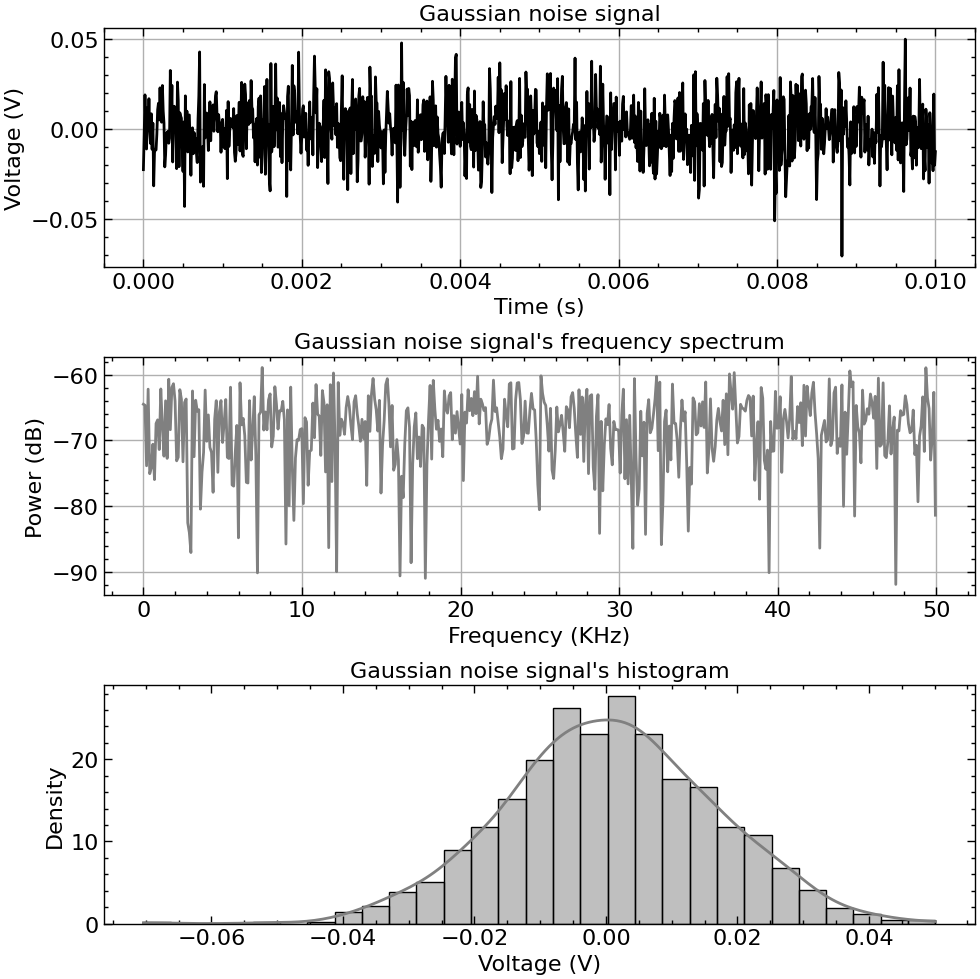

In [15]:
vqmean = 0  # [V]
vqvar = (vlsb**2) / 12  # [V^2]
vqstddev = np.sqrt(vqvar)  # [V]

vq = normal(vqmean, vqstddev, Np)  # [V]

vqf = np.abs(np.fft.fftshift(np.fft.fft(vq) / Np))  # [V]
pqf = vqf * vqf  # [V^2]
pqf_dB = 10 * np.log10(pqf)  # [dB]

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(tD, vq, ls="-", color="k", marker="none")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Voltage (V)")
ax[0].set_title("Gaussian noise signal")
ax[1].plot(
    fD[fD >= 0] / f_scale,
    pqf_dB[fD >= 0] / p_scale,
    ls="-",
    color="gray",
    marker="none",
)
ax[1].set_xlabel("Frequency (KHz)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_title("Gaussian noise signal's frequency spectrum")
sns.histplot(vq, ax=ax[2], kde=True, stat="density", color="gray")
ax[2].set_xlabel("Voltage (V)")
ax[2].set_ylabel("Density")
ax[2].set_title("Gaussian noise signal's histogram")
ax[0].grid()
ax[1].grid()
ax[2].grid(False)
fig.tight_layout()

### 3.3 Signal with Superimposed Quantization Noise

Adding quantization noise to a sinusoidal signal produces a noisy waveform whose spectrum shows the signal tone rising above a flat noise floor — the hallmark of a quantized signal.

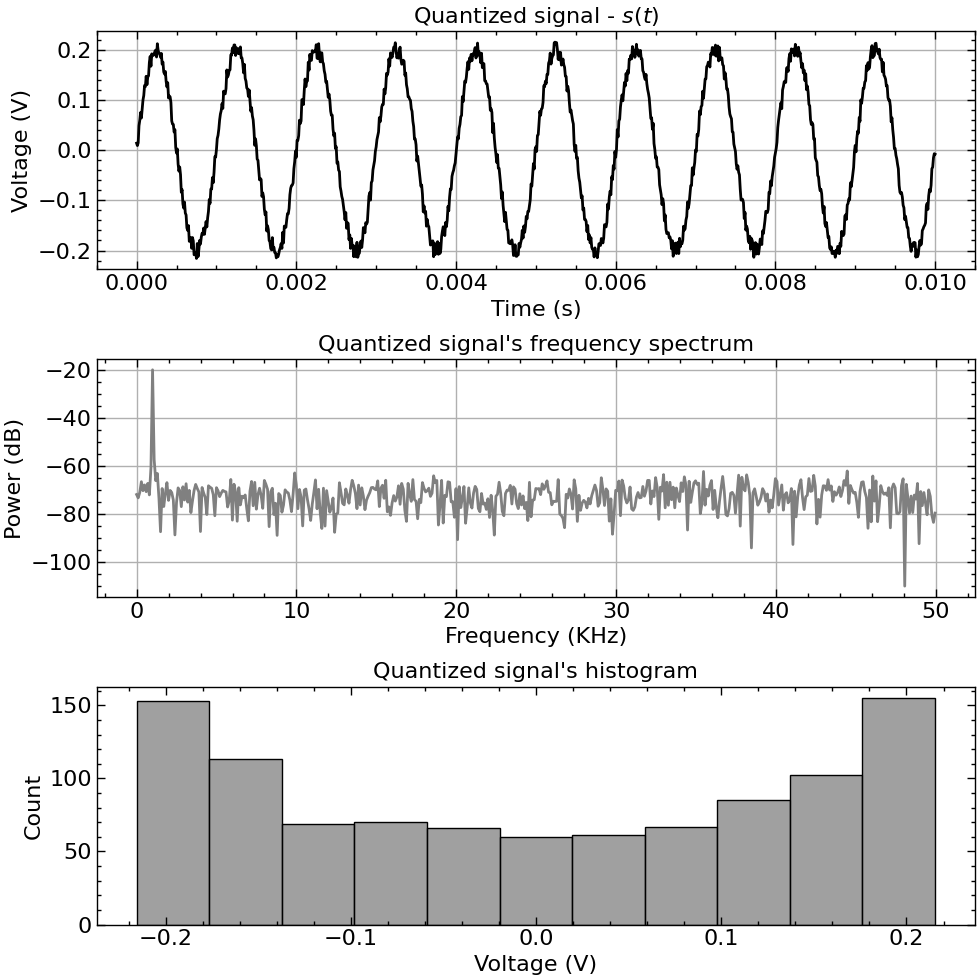

In [16]:
Amp1 = 0.2  # [V]
x1 = Amp1 * np.sin(2 * np.pi * f1 * tD + phase1_rad)  # [V]
vq = uniform(-vqstddev, vqstddev, Np)  # [V]
st = x1 + vq

stf = np.abs(np.fft.fftshift(np.fft.fft(st) / Np))  # [V]
ptf = stf * stf  # [V^2]
ptf_dB = 10 * np.log10(ptf)  # [dB]

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(tD, st, ls="-", color="k", marker="none")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Voltage (V)")
ax[0].set_title(r"Quantized signal - $s(t)$")
ax[1].plot(
    fD[fD >= 0] / f_scale,
    ptf_dB[fD >= 0] / p_scale,
    ls="-",
    color="gray",
    marker="none",
)
ax[1].set_xlabel("Frequency (KHz)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_title("Quantized signal's frequency spectrum")
sns.histplot(st, ax=ax[2], color="gray")
ax[2].set_xlabel("Voltage (V)")
ax[2].set_ylabel("Count")
ax[2].set_title("Quantized signal's histogram")
ax[0].grid()
ax[1].grid()
ax[2].grid(False)
fig.tight_layout()